In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/matthewtwigge/financial-performance-analysis/financial_performance_analysis.csv


In [3]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.2f}'.format)

df = pd.read_csv('/kaggle/input/datasets/matthewtwigge/financial-performance-analysis/financial_performance_analysis.csv')

print(df.shape)
print(df.head())
print(df.columns.tolist())

(701, 20)
          Segment  Country      Product Discount Band  Units Sold  \
0      Government   Canada     Montana          High       200.00   
1  Small Business  Germany   Carretera           Low       214.00   
2  Small Business  Germany         VTT           Low       214.00   
3       Midmarket   Canada       Paseo           Low       218.00   
4      Government  Germany       Paseo          High       241.00   

   Manufacturing Price  Sale Price  Gross Sales  Discounts Discounts %  \
0                 5.00      350.00     70000.00    9800.00      14.00%   
1                 3.00      300.00     64200.00    1284.00       2.00%   
2               250.00      300.00     64200.00    1284.00       2.00%   
3                10.00       15.00      3270.00     130.80       4.00%   
4                10.00       20.00      4820.00     482.00      10.00%   

     Sales     COGS  COGS %  Profit Profit Margin % Profit Category  \
0 60200.00 52000.00  86.38% 8200.00          11.71%        

In [4]:
# Convert percentage columns from string to numeric
pct_columns = ['Discounts %', 'COGS %', 'Profit Margin %']

for col in pct_columns:
    df[col] = df[col].str.replace('%', '').str.strip().astype(float) / 100

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Confirm cleaned dtypes
print(df[pct_columns].dtypes)
print(df[pct_columns].head())

Discounts %        float64
COGS %             float64
Profit Margin %    float64
dtype: object
   Discounts %  COGS %  Profit Margin %
0         0.14    0.86             0.12
1         0.02    0.85             0.15
2         0.02    0.85             0.15
3         0.04    0.69             0.29
4         0.10    0.56             0.40


## 1. Data Cleaning
Percentage columns (Discounts %, COGS %, Profit Margin %) were loaded as 
strings due to the % symbol from Excel. These were converted to float64 
for numerical analysis. Date column converted to datetime format.

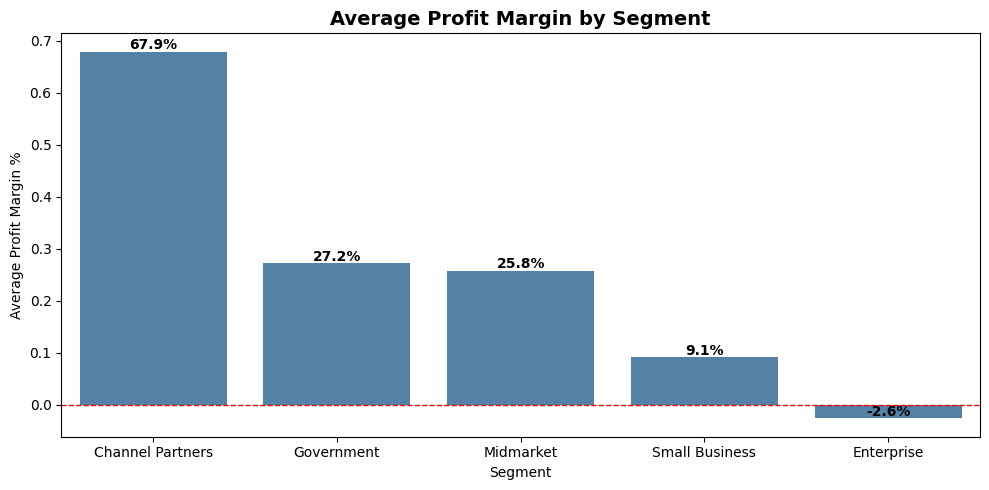

In [5]:
segment_margin = df.groupby('Segment')['Profit Margin %'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=segment_margin, x='Segment', y='Profit Margin %', color='steelblue')
plt.title('Average Profit Margin by Segment', fontsize=14, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Average Profit Margin %')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)

# Add percentage labels on each bar
for i, row in segment_margin.iterrows():
    ax.text(i, row['Profit Margin %'] + 0.005, 
            f"{row['Profit Margin %']:.1%}", 
            ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### Key Insight: Profit Margin by Segment

- Channel Partners is the most profitable segment at 67.92% average margin
- Enterprise is the only loss-making segment at -2.60% average margin
- Government, Midmarket and Small Business deliver modest but positive margins
- The spread between best (67.92%) and worst (-2.60%) segment is over 70 percentage points
- The red line at zero makes loss-making activity immediately visible

**Business Recommendation:** Urgent review of Enterprise pricing strategy is required. 
The business is losing money on every Enterprise transaction while Channel Partners 
deliver nearly 68% margins — a 70 point gap that represents a significant 
strategic misalignment.

## 2. Exploratory Data Analysis

### 2.1 Monthly Revenue and Profit Trend
Analysing how revenue and profit perform across the two year period 
to identify seasonality and growth patterns.

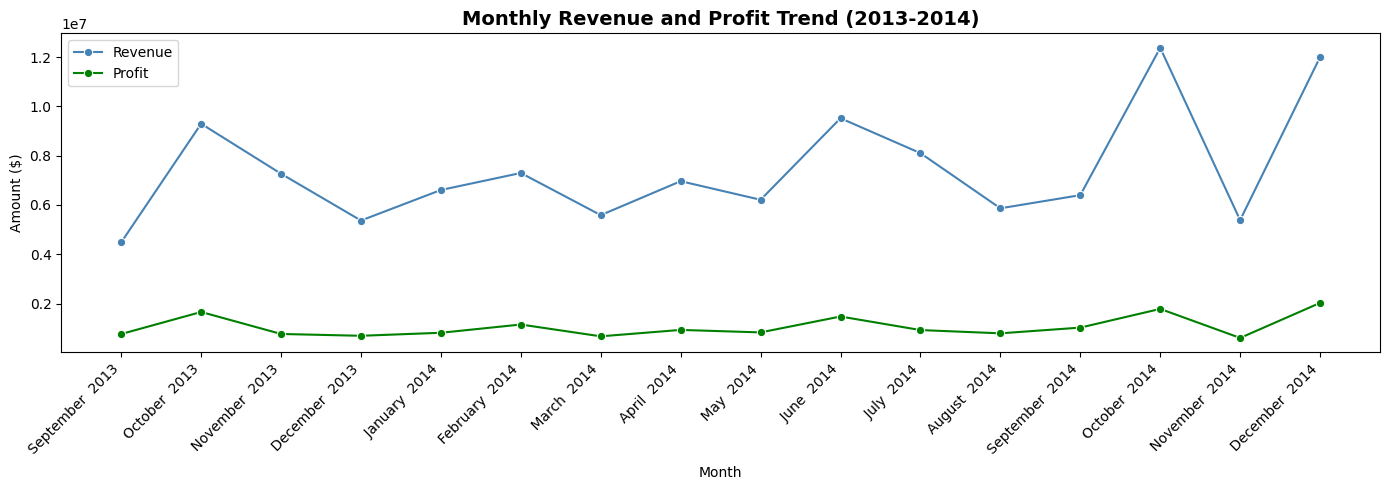

In [6]:
monthly = df.groupby(['Year', 'Month Number', 'Month Name']).agg(
    Revenue=('Sales', 'sum'),
    Profit=('Profit', 'sum')
).reset_index().sort_values(['Year', 'Month Number'])

monthly['YearMonth'] = monthly['Month Name'] + ' ' + monthly['Year'].astype(int).astype(str)

plt.figure(figsize=(14, 5))
sns.lineplot(data=monthly, x='YearMonth', y='Revenue', marker='o', color='steelblue', label='Revenue')
sns.lineplot(data=monthly, x='YearMonth', y='Profit', marker='o', color='green', label='Profit')
plt.xticks(rotation=45, ha='right')
plt.title('Monthly Revenue and Profit Trend (2013-2014)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Amount ($)')
plt.legend()
plt.tight_layout()
plt.show()

### Key Insight: Monthly Revenue and Profit Trend

- October is the peak month in both 2013 and 2014 — a consistent 
  seasonal pattern the business should plan around
- December 2014 significantly outperformed December 2013, suggesting 
  strong year on year Q4 growth
- November 2014 shows an unexpected dip before the December spike — 
  possibly reflecting a timing shift in customer ordering behaviour
- Profit closely tracks revenue throughout both years, indicating 
  stable margins with no significant seasonal cost spikes
- Overall 2014 outperforms 2013 across most months, suggesting 
  positive business trajectory

### 2.2 Revenue and Profit by Country
Identifying which markets drive the most revenue and profit.

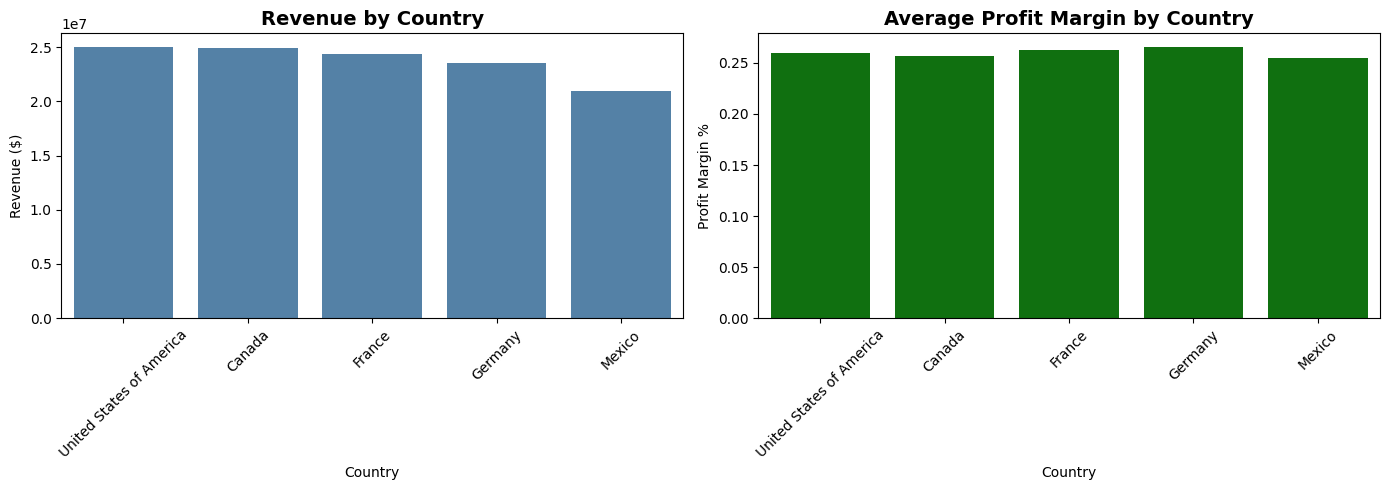

                    Country     Revenue     Profit  Margin
4  United States of America 25029830.18 2995540.68    0.26
0                    Canada 24887654.89 3529228.89    0.26
1                    France 24354172.29 3781020.79    0.26
2                   Germany 23505340.82 3680388.82    0.27
3                    Mexico 20949352.11 2907523.11    0.25


In [7]:
country = df.groupby('Country').agg(
    Revenue=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Margin=('Profit Margin %', 'mean')
).reset_index().sort_values('Revenue', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Revenue by country
sns.barplot(data=country, x='Country', y='Revenue', color='steelblue', ax=axes[0])
axes[0].set_title('Revenue by Country', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Country')
axes[0].set_ylabel('Revenue ($)')
axes[0].tick_params(axis='x', rotation=45)

# Profit margin by country
sns.barplot(data=country, x='Country', y='Margin', color='green', ax=axes[1])
axes[1].set_title('Average Profit Margin by Country', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Country')
axes[1].set_ylabel('Profit Margin %')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(country)

### Key Insight: Revenue and Profit by Country

- All five markets deliver consistent margins between 25-27% — 
  geography is not a driver of profitability variance
- USA leads on revenue at $25M but Germany delivers the strongest 
  margin at 27% despite ranking 4th for revenue
- Mexico is the smallest market by both revenue and margin — 
  worth monitoring for growth potential
- Consistent country performance confirms that profitability issues 
  are driven by segment mix, not geographic factors
- This finding is consistent with the Excel pivot table analysis


### 2.3 Profit Margin by Discount Band
Examining how discounting behaviour impacts profit margins across the business.

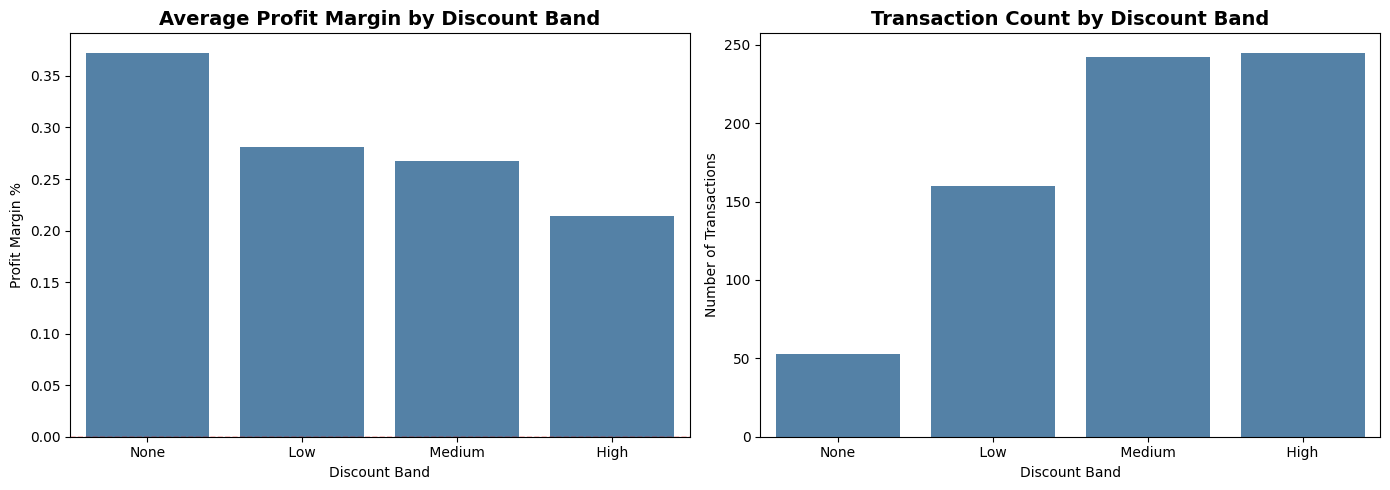

  Discount Band     Revenue     Profit  Margin  Transactions
3          None  7943654.00 1736455.00    0.37            53
1          Low  34629778.71 6188857.71    0.28           160
2       Medium  38780430.84 5579522.84    0.27           242
0         High  37372486.74 3388866.74    0.21           245


In [15]:
discount = df.groupby('Discount Band').agg(
    Revenue=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Margin=('Profit Margin %', 'mean'),
    Transactions=('Sales', 'count')
).reset_index().sort_values('Margin', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Margin by discount band
sns.barplot(data=discount, x='Discount Band', y='Margin', color='steelblue', ax=axes[0])
axes[0].set_title('Average Profit Margin by Discount Band', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Discount Band')
axes[0].set_ylabel('Profit Margin %')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1)

# Transaction count by discount band
sns.barplot(data=discount, x='Discount Band', y='Transactions', color='steelblue', ax=axes[1])
axes[1].set_title('Transaction Count by Discount Band', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Discount Band')
axes[1].set_ylabel('Number of Transactions')

plt.tight_layout()
plt.show()

print(discount)

In [9]:
print(df['Discount Band'].value_counts())
print(df['Discount Band'].isnull().sum())

Discount Band
High       245
Medium     242
Low        160
Name: count, dtype: int64
54


In [14]:
df['Discount Band'] = df['Discount Band'].fillna('None')

print(df['Discount Band'].value_counts())

Discount Band
 High       245
 Medium     242
 Low        160
None         54
Name: count, dtype: int64


### Key Insight: Profit Margin by Discount Band

- Undiscounted transactions deliver 37% average margin versus 
  21% for heavily discounted transactions — a 16 point gap
- High discount is the most common transaction type (245) but 
  delivers the lowest margins — the business is running its 
  highest volume at its lowest profitability
- None discount transactions (53) generate 1.7M profit from 
  7.9M revenue — more efficient than High discount which 
  generates 3.4M profit from 37.4M revenue
- Reducing reliance on high discounting is one of the clearest
  levers available to improve overall profitability

**Business Recommendation:** Review the discounting strategy, 
particularly in segments where High discounts are most common. 
Combined with the Enterprise segment finding, aggressive discounting 
in low margin segments may be compounding the profitability problem.


### 2.4 Product Performance Analysis
Examining revenue, profit and margin across all six products 
to identify the strongest and weakest performers.

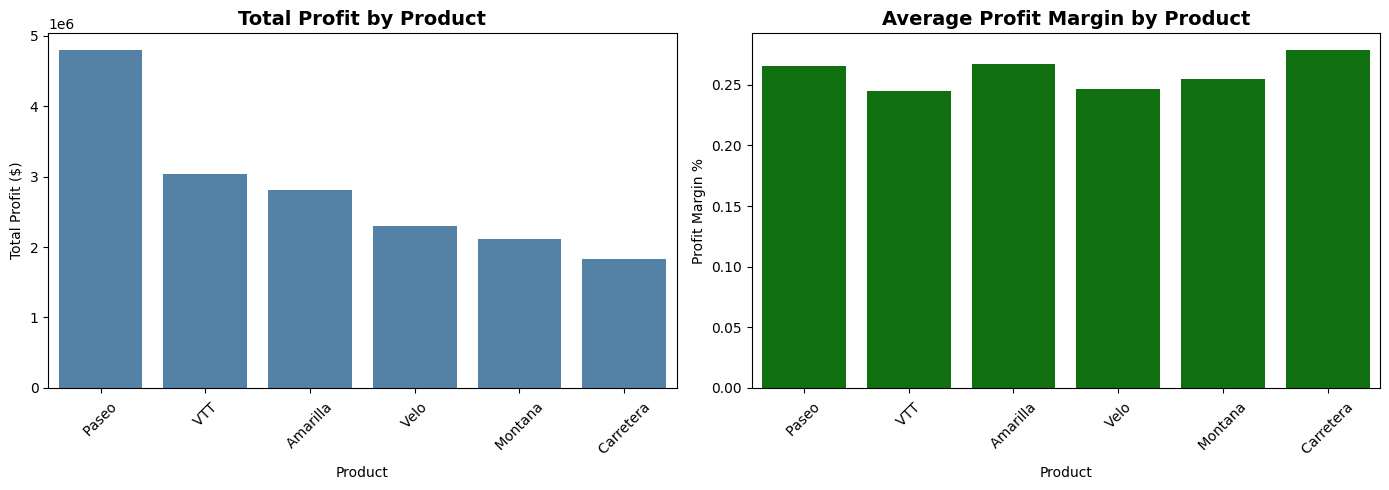

       Product     Revenue     Profit  Margin     Units
3       Paseo  33011143.96 4797437.96    0.27 338239.50
4         VTT  20511921.02 3034608.02    0.25 168783.00
0    Amarilla  17747116.07 2814104.07    0.27 155315.00
5        Velo  18250059.47 2305992.47    0.25 162424.50
2     Montana  15390801.88 2114754.88    0.25 154198.00
1   Carretera  13815307.89 1826804.89    0.28 146846.00


In [11]:
product = df.groupby('Product').agg(
    Revenue=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Margin=('Profit Margin %', 'mean'),
    Units=('Units Sold', 'sum')
).reset_index().sort_values('Profit', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Profit by product
sns.barplot(data=product, x='Product', y='Profit', color='steelblue', ax=axes[0])
axes[0].set_title('Total Profit by Product', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Product')
axes[0].set_ylabel('Total Profit ($)')
axes[0].tick_params(axis='x', rotation=45)

# Margin by product
sns.barplot(data=product, x='Product', y='Margin', color='green', ax=axes[1])
axes[1].set_title('Average Profit Margin by Product', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Product')
axes[1].set_ylabel('Profit Margin %')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(product)

### Key Insight: Product Performance

- Paseo is the volume and profit leader generating 33M revenue 
  and 4.8M profit — the clear hero product
- Carretera delivers the highest margin at 28% despite the lowest 
  revenue — the most capital efficient product in the portfolio
- All six products deliver positive margins between 25-28% — 
  product mix is not a driver of the profitability problems 
  identified at segment level
- Growing Carretera volume while maintaining its margin premium 
  represents a significant profit opportunity

**Business Recommendation:** Investigate what drives Carretera's 
margin premium and whether those conditions can be replicated 
across other products. Focus volume growth efforts on 
high margin products rather than high volume low margin ones.

### 2.5 Segment and Discount Band Heatmap
Examining the relationship between customer segment and discount band 
to identify where heavy discounting is most concentrated.

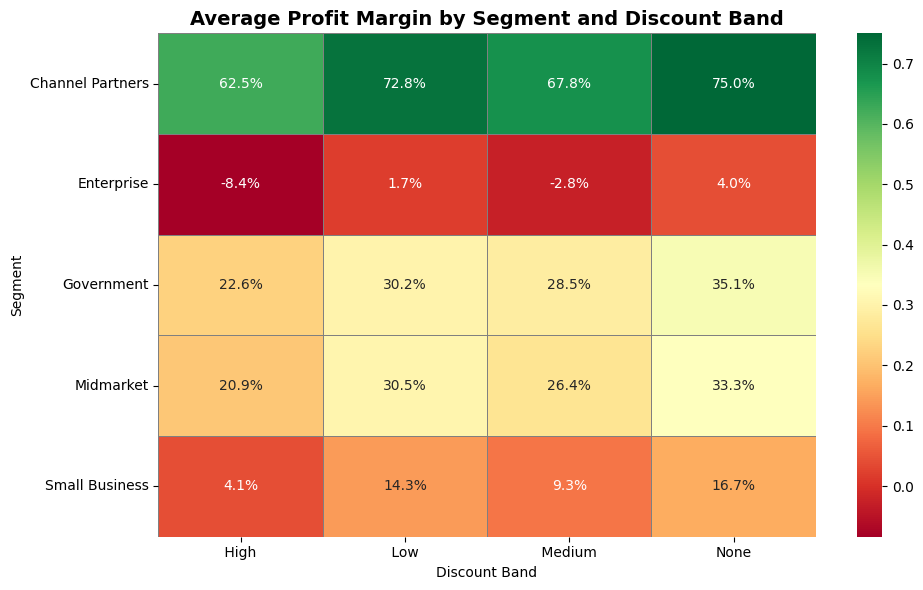

In [12]:
heatmap_data = df.groupby(['Segment', 'Discount Band'])['Profit Margin %'].mean().unstack()

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.1%', cmap='RdYlGn',
            linewidths=0.5, linecolor='grey')
plt.title('Average Profit Margin by Segment and Discount Band', 
          fontsize=14, fontweight='bold')
plt.xlabel('Discount Band')
plt.ylabel('Segment')
plt.tight_layout()
plt.show()

### Key Insight: Segment and Discount Band Heatmap

- Enterprise transactions are loss making across all discount bands — 
  even undiscounted Enterprise sales barely break even
- Channel Partners maintain strong green margins across all discount 
  bands — the most resilient segment commercially
- Government and Midmarket are discount sensitive — None discount 
  delivers 35% and 33% margins respectively, dropping significantly 
  with higher discounts
- The heatmap confirms that Enterprise discounting is the most 
  damaging combination in the business — negative margins 
  compounded by aggressive discounting
- Small Business delivers modest margins across all discount bands 
  (4.1% at High to 16.7% at None) — no loss making transactions 
  but consistently the weakest performing non-Enterprise segment. 
  Heavy discounting in Small Business should be avoided given the 
  already thin margin baseline.

**Business Recommendation:** Immediately remove discounting from 
Enterprise transactions. With already negative baseline margins, 
any discount in this segment directly destroys value. 
prioritise None and Low discount transactions in Government 
and Midmarket to protect margins in these segments.

In [13]:
import sqlite3

# Export cleaned dataframe to CSV for DB Browser
df.to_csv('financial_cleaned.csv', index=False)
print("Exported successfully")
print(df.shape)

Exported successfully
(701, 20)
